In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os, copy, pickle, time

from pypower.makeYbus import makeYbus
from default_args import *
from flows_utils import ActNorm, LUInvertibleMM, MADE, INN, Sigmoid
from training_utils import *
from sampling_utils import *
from optimization_utils import ACOPFProblem
from plot_utils import *
from training_all import eval_solution, test_mdh_mapping, test_nn_solver
print('done')


done


In [11]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {DEVICE}")

Training on: cpu


In [ ]:
def config():
    defaults = {}
    defaults['predType'] = ['NN', 'NN_Eq'][1]
    defaults['projType'] = ['WS', 'Proj', 'D_Proj', 'H_Bis'][3]
    defaults['probType'] = ['qp', 'socp', 'convex_qcqp', 'sdp', 'acopf'][4]
    defaults['probSize'] = [[100, 50, 50, 10000],
                            [200, 100, 100, 20000]][1]
    defaults['opfSize'] = [30,  10000]
    defaults['testSize'] = 1000
    defaults['saveAllStats'] = True
    defaults['resultsSaveFreq'] = 1000
    defaults['seed'] = 2026

    defaults['mapping_para'] = \
        {'training': True, 'testing': True,
        'n_samples': 1024,
        't_samples': 10000,
        'bound': [0, 1],
        'scale_ratio': 1,
        'shape': 'square',
        'total_iteration': 2000, 
        'batch_size': 1024,
        'num_layer': 3,
        'lr': 1e-4,
        'lr_decay': 0.9,
        'lr_decay_step': 1000,
        'penalty_coefficient': 10,
        'distortion_coefficient': 1,
        'transport_coefficient': 0,
        'testing_samples': 1024}


    defaults['nn_para'] = \
        {'training': False, 'testing': False,
         'approach': 'unsupervise',
        'total_iteration': 5000,
        'batch_size': 1024,
        'lr': 1e-3,
        'lr_decay': 0.9,
        'lr_decay_step': 1000,
        'num_layer': 3,
        'objWeight': 0.1,
        'softWeightInEqFrac': 10,
        'softWeightEqFrac': 10}


    defaults['proj_para'] = \
        {'useTestCorr': True,    # post-process for infeasible solutions
        'corrMode': 'partial',    # equality completion  
        'corrTestMaxSteps': 100,  # steps for D-Proj
        'corrBis': 0.9,           # steps for bisection
        'corrEps': 1e-5,          # tolerance for constraint violation
        'corrLr': 1e-5,           # stepsize for gradient descent in D-Proj
        'corrMomentum': 0.1, }    # momentum parameter in D-Proj

    return defaults

In [13]:
def load_instance(args):
    # Load data, and put on GPU if needed
    seed = args['seed']
    args['algoType'] = args['predType'] + args['projType']
    test_size = args['testSize']
    prob_type = args['probType']
    if prob_type in ['acopf']:
        filepath = os.path.join('datasets', prob_type, 'acopf_{}_{}_{}_dataset'.format(
            seed, args['opfSize'][0], args['opfSize'][1]))
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        data = ACOPFProblem(dataset, test_size)
    else:
        NotImplementedError
        print("Not Implement Instance")

    data.device = DEVICE
    print(DEVICE)
    for attr in dir(data):
        var = getattr(data, attr)
        if torch.is_tensor(var):
            try:
                setattr(data, attr, var.to(DEVICE))
            except AttributeError:
                pass

    result_save_dir = os.path.join('results', prob_type, str(data), args['algoType'])
    model_save_dir = os.path.join('models', prob_type, str(data), args['predType'])
    if not os.path.exists(model_save_dir):
        os.makedirs(model_save_dir)
    if not os.path.exists(result_save_dir):
        os.makedirs(result_save_dir)
    with open(os.path.join(model_save_dir, 'args.dict'), 'wb') as f:
        pickle.dump(args, f)

    return data, result_save_dir, model_save_dir


In [ ]:
def train_mdh_mapping(data, args, save_dir):
    paras = args['mapping_para']
    ### input pparameters --> output solutions
    t_tensor = data.X.squeeze()
    x_tensor = data.Y[:, data.partial_unknown_vars].squeeze()
    t_samples, t_dim = t_tensor.shape
    n_samples, n_dim = x_tensor.shape
    #### Flow-based model: ball -> constraint set
    mask = torch.zeros(size=[1,n_dim], device=DEVICE)
    mask[:, :n_dim//2] = 1
    num_layer = paras['num_layer']
    flow_modules = []
    for _ in range(num_layer):
        flow_modules += [ActNorm(num_inputs=n_dim),
                         LUInvertibleMM(num_inputs=n_dim),
                         ActNorm(num_inputs=n_dim),
                         MADE(num_inputs=n_dim, num_hidden=n_dim//2, num_cond_inputs=t_dim)]
                                #  CouplingLayer(n_dim, n_dim//2, mask, t_dim)]
    flow_modules += [ActNorm(num_inputs=n_dim), Sigmoid()]
    model = INN(flow_modules, None).to(device=DEVICE)
    optimizer = optim.Adam(model.parameters(),
                           lr=paras['lr'],
                           weight_decay=1e-6)
    scheduler = optim.lr_scheduler.StepLR(optimizer,
                                          step_size=paras['lr_decay_step'],
                                          gamma=paras['lr_decay'])
    #### Sampling input parameters and output decision
    initial_shape = paras['shape']
    bound = paras['bound']  # initial shape to [0,1] bounded constraint set
    x_train = sampling_body(paras['n_samples'], n_dim, initial_shape, lu=bound)
    x_train_tensor = torch.tensor(x_train).view(-1, n_dim).to(device=DEVICE)
    t_train_tensor = torch.rand([paras['t_samples'], t_dim]).to(device=DEVICE)
    t_train_tensor = t_train_tensor * (data.input_U - data.input_L) + data.input_L

    #### Unsupervised Training for Homeo Mapping
    model, volume_list, penalty_list, dist_list, trans_list = training(model, data, 
                                                                       optimizer, scheduler,
                                                                       x_train_tensor, t_train_tensor, 
                                                                       paras)
    plot_convergence(volume_list, penalty_list, dist_list, trans_list, save_dir)
    torch.save(model, os.path.join(save_dir, 'mapping.pth'))

def train_nn_solver(data, args, save_dir):
    lr = args['nn_para']['lr']
    nepochs = args['nn_para']['total_iteration']
    batch_size = args['nn_para']['batch_size']
    lr_decay = args['nn_para']['lr_decay']
    lr_decay_step = args['nn_para']['lr_decay_step']
    training_appoach = args['nn_para']['approach']
    ## Run pure optimization baselines
    # if args['probType'] == 'acopf':
    #     solvers = ['pypower']
    # else:
    #     solvers = ['cvxpy']  # 'qpth osqp'
    # _, _, opt_time = data.opt_solve(data.testX[:2], solver_type=solvers[0], tol=args['proj_para']['corrEps'])
    # print(f'full paralell pure opt time {opt_time}')
    # print('solution range', torch.max(data.trainY), torch.min(data.trainY))

    ### Equality completion
    if 'Eq' in args['algoType']:
        out_dim = len(data.partial_unknown_vars)
    ### Direct
    else:
        out_dim = data.testY.shape[1]

    in_dim = data.xdim
    hidden_dim = (in_dim + out_dim) // 2
    solver_net = NNSolver(data.xdim, out_dim, hidden_dim, args)
    solver_net.to(DEVICE)
    solver_opt = optim.Adam(solver_net.parameters(), lr=lr, weight_decay=1e-5)
    solver_shce = optim.lr_scheduler.StepLR(solver_opt, step_size=lr_decay_step, gamma=lr_decay)
    try:
        homeo_mapping = torch.load(os.path.join(save_dir, 'mapping.pth'), map_location=DEVICE, weights_only=False)
    except:
        homeo_mapping = None
    stats = {}
    solver_net.train()

    Xtrain = data.trainX.to(DEVICE)
    Ytrain = data.trainY.squeeze().to(DEVICE)
    Xtest = data.testX.to(DEVICE)
    Ytest = data.testY.squeeze().to(DEVICE)

    for i in range(nepochs + 1):
        epoch_stats = {}
        if training_appoach == 'supervise':
            batch_index = np.random.choice(np.arange(Xtrain.shape[0]), batch_size, replace=True)
            # Get train loss
            Xtrain_batch = Xtrain[batch_index]
            Ytrain_batch = Ytrain[batch_index]
            start_time = time.time()
            Y_pred_batch = solver_net(Xtrain_batch)
            Y_pred_scale_batch = data.scale(Xtrain_batch, Y_pred_batch)
            if 'Eq' in args['algoType']:
                Y_pred_scale_batch = data.complete_partial(Xtrain_batch, Y_pred_scale_batch)
            training_obj = data.obj_fn(Y_pred_scale_batch)
            real_obj = data.obj_fn(Ytrain_batch)
            eq_penalty = torch.sum(torch.abs(data.eq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            ineq_penalty = torch.sum(torch.abs(data.ineq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            mse_loss = nn.MSELoss(reduction='none')(Y_pred_scale_batch, Ytrain_batch).sum(dim=1)
            train_loss = mse_loss \
                        + args['nn_para']['softWeightInEqFrac'] * ineq_penalty \
                        + args['nn_para']['softWeightEqFrac'] * eq_penalty \
                        + args['nn_para']['objWeight'] * training_obj
        else:
            Xtrain_batch = torch.rand([batch_size, Xtest.shape[1]]).to(device=DEVICE)
            Xtrain_batch = Xtrain_batch * (data.input_U - data.input_L) + data.input_L
            start_time = time.time()
            Y_pred_batch = solver_net(Xtrain_batch)
            Y_pred_scale_batch = data.scale(Xtrain_batch, Y_pred_batch)
            if 'Eq' in args['algoType']:
                Y_pred_scale_batch = data.complete_partial(Xtrain_batch, Y_pred_scale_batch)
            training_obj = data.obj_fn(Y_pred_scale_batch)
            eq_penalty = torch.sum(torch.abs(data.eq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            ineq_penalty = torch.sum(torch.abs(data.ineq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            train_loss = args['nn_para']['softWeightInEqFrac'] * ineq_penalty \
                        + args['nn_para']['softWeightEqFrac'] * eq_penalty \
                        + args['nn_para']['objWeight'] * training_obj

        train_loss.mean().backward()
        solver_opt.step()
        solver_shce.step()
        solver_opt.zero_grad()
        train_time = time.time() - start_time
        dict_agg(epoch_stats, 'train_loss', train_loss.detach().cpu().numpy())
        dict_agg(epoch_stats, 'train_obj', training_obj.detach().cpu().numpy())
        # dict_agg(epoch_stats, 'train_real_obj', real_obj.detach().cpu().numpy())
        dict_agg(epoch_stats, 'train_time', train_time, op='sum')

        # Print results
        if i % args['resultsSaveFreq'] == 0 and i > 0:
            solver_net.eval()
            with torch.no_grad():
                eval_solution(data, Xtest, Ytest, solver_net, homeo_mapping, args, 'test', epoch_stats)
            print('Epoch:{}\n'
                  'Raw_loss: MSE({:.4f}), MAE({:.4f}), MAP({:.4f}),     Raw_obj: MSE({:.4f}), MAE({:.4f}), MAP({:.4f}) \n'
                  'Raw_Ineq: Max({:.4f}), Sum({:.4f}), Per({:.4f}),     Raw_eq:  Max({:.4f}), Sum({:.4f}), Per({:.4f})\n'.format(
                i,
                np.mean(epoch_stats['test_raw_mse_loss']), np.mean(epoch_stats['test_raw_mae_loss']),
                np.mean(epoch_stats['test_raw_mape_loss']), np.mean(epoch_stats['test_raw_obj_mse']),
                np.mean(epoch_stats['test_raw_obj_mae']), np.mean(epoch_stats['test_raw_obj_mape']),
                np.mean(epoch_stats['test_raw_ineq_max']), np.mean(epoch_stats['test_raw_ineq_sum']),
                np.mean(epoch_stats['test_raw_ineq_num_viol_0']) / data.nineq,
                np.mean(epoch_stats['test_raw_eq_max']),
                np.mean(epoch_stats['test_raw_eq_sum']), np.mean(epoch_stats['test_raw_eq_num_viol_0']) / data.neq))
            with open(os.path.join(save_dir, 'solver_net.pth'), 'wb') as f:
                torch.save(solver_net, f)
        if args['saveAllStats']:
            if i == 0:
                for key in epoch_stats.keys():
                    stats[key] = np.expand_dims(np.array(epoch_stats[key]), axis=0)
            else:
                for key in epoch_stats.keys():
                    stats[key] = np.concatenate((stats[key], np.expand_dims(np.array(epoch_stats[key]), axis=0)))
        else:
            stats = epoch_stats
    with open(os.path.join(save_dir, 'train_stats.dict'), 'wb') as f:
        pickle.dump(stats, f)
    return solver_net, stats


In [15]:
def run_instance(args):

    """
    Load data
    """
    data, result_save_dir, model_save_dir = load_instance(args)
    # print(args['probType'], args['probSize'])

    """
    Run homeomorphic mapping
    """
    if args['mapping_para']['training']:
        train_mdh_mapping(data, args, model_save_dir)
    if args['mapping_para']['testing']:
        test_mdh_mapping(data, model_save_dir, args)

    """
    Run neural network solver
    """
    if args['nn_para']['training']:
        train_nn_solver(data, args, model_save_dir)
    if args['nn_para']['testing']:
        test_nn_solver(data, args, model_save_dir, result_save_dir)

def load_instance(args):
    # Load data, and put on GPU if needed
    seed = args['seed']
    args['algoType'] = args['predType'] + args['projType']
    test_size = args['testSize']
    prob_type = args['probType']
    if prob_type in ['acopf']:
        filepath = os.path.join('datasets', prob_type, 'acopf_{}_{}_{}_dataset'.format(
            seed, args['opfSize'][0], args['opfSize'][1]))
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        data = ACOPFProblem(dataset, test_size)
    else:
        NotImplementedError
        print("Not Implement Instance")

    data.device = DEVICE
    print(DEVICE)
    for attr in dir(data):
        var = getattr(data, attr)
        if torch.is_tensor(var):
            try:
                setattr(data, attr, var.to(DEVICE))
            except AttributeError:
                pass

    result_save_dir = os.path.join('results', prob_type, str(data), args['algoType'])
    model_save_dir = os.path.join('models', prob_type, str(data), args['predType'])
    if not os.path.exists(model_save_dir):
        os.makedirs(model_save_dir)
    if not os.path.exists(result_save_dir):
        os.makedirs(result_save_dir)
    with open(os.path.join(model_save_dir, 'args.dict'), 'wb') as f:
        pickle.dump(args, f)

    return data, result_save_dir, model_save_dir


In [16]:
# 1. Load the configuration dictionary
args = config()
# 2. Ensure the problem type is set correctly
args['probType'] = 'acopf'
# 3. Explicitly set the dataset size just to be safe 
# (Even though it is in config(), this makes it easy to change later)
args['opfSize'] = [89, 10]

Starting Homeomorphic Projection pipeline...
Dataset: 89-bus system, 10 scenarios.
Seed: 2026
--------------------------------------------------
178 226 202 178
cpu
--------------------------------------------------
Training Pipeline Complete!


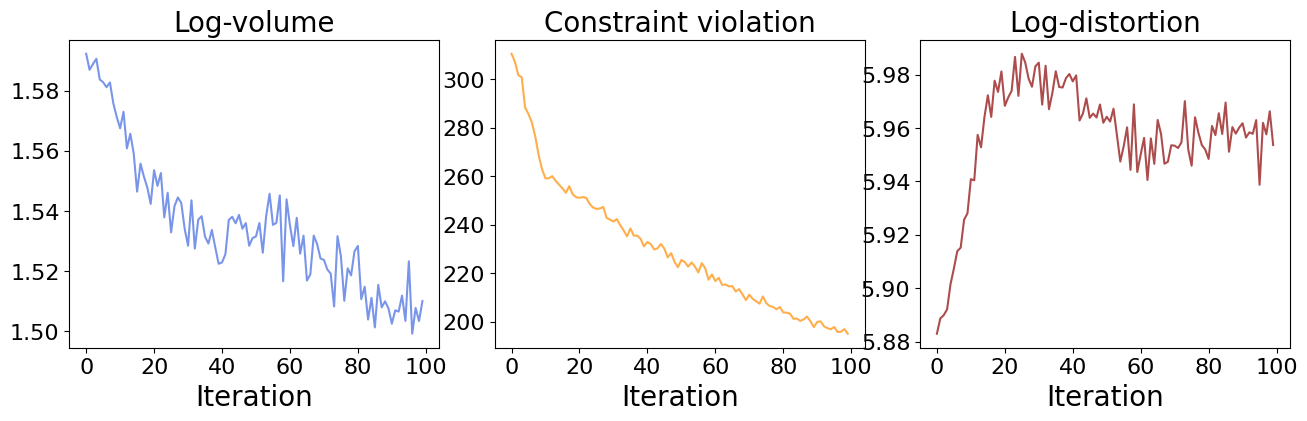

In [17]:
# 4. Trigger the Director function
print(f"Starting Homeomorphic Projection pipeline...")
print(f"Dataset: {args['opfSize'][0]}-bus system, {args['opfSize'][1]} scenarios.")
print(f"Seed: {args['seed']}")
print("-" * 50)

# This will run the mapping phase, then the solver phase sequentially!
run_instance(args)

print("-" * 50)
print("Training Pipeline Complete!")